
pred_len = 1
  215 (10 seeds): F1=0.985  95%CI=[0.966, 1.000]
  213 (10 seeds): F1=0.349  95%CI=[0.228, 0.450]
  209 (10 seeds): F1=0.884  95%CI=[0.816, 0.925]
  203 (10 seeds): F1=0.584  95%CI=[0.482, 0.667]
  210 (10 seeds): F1=0.892  95%CI=[0.841, 0.937]
  116 (10 seeds): F1=0.970  95%CI=[0.870, 0.990]
  222 (10 seeds): F1=0.262  95%CI=[0.152, 0.358]
  233 (10 seeds): F1=0.980  95%CI=[0.955, 0.995]
  118 (10 seeds): F1=0.423  95%CI=[0.307, 0.535]
  223 (10 seeds): F1=0.761  95%CI=[0.688, 0.828]
  221 (10 seeds): F1=0.976  95%CI=[0.953, 0.995]
  214 (10 seeds): F1=0.961  95%CI=[0.929, 0.986]
  200 (10 seeds): F1=0.636  95%CI=[0.514, 0.738]
  228 (10 seeds): F1=0.888  95%CI=[0.837, 0.932]
  201 (10 seeds): F1=0.945  95%CI=[0.400, 0.977]
  208 (10 seeds): F1=0.641  95%CI=[0.550, 0.727]
  119 (10 seeds): F1=0.952  95%CI=[0.921, 0.981]
  207 (10 seeds): F1=0.309  95%CI=[0.193, 0.426]
  106 (10 seeds): F1=0.935  95%CI=[0.901, 0.967]

pred_len = 10
  215 (10 seeds): F1=0.926  95%CI=[0.887

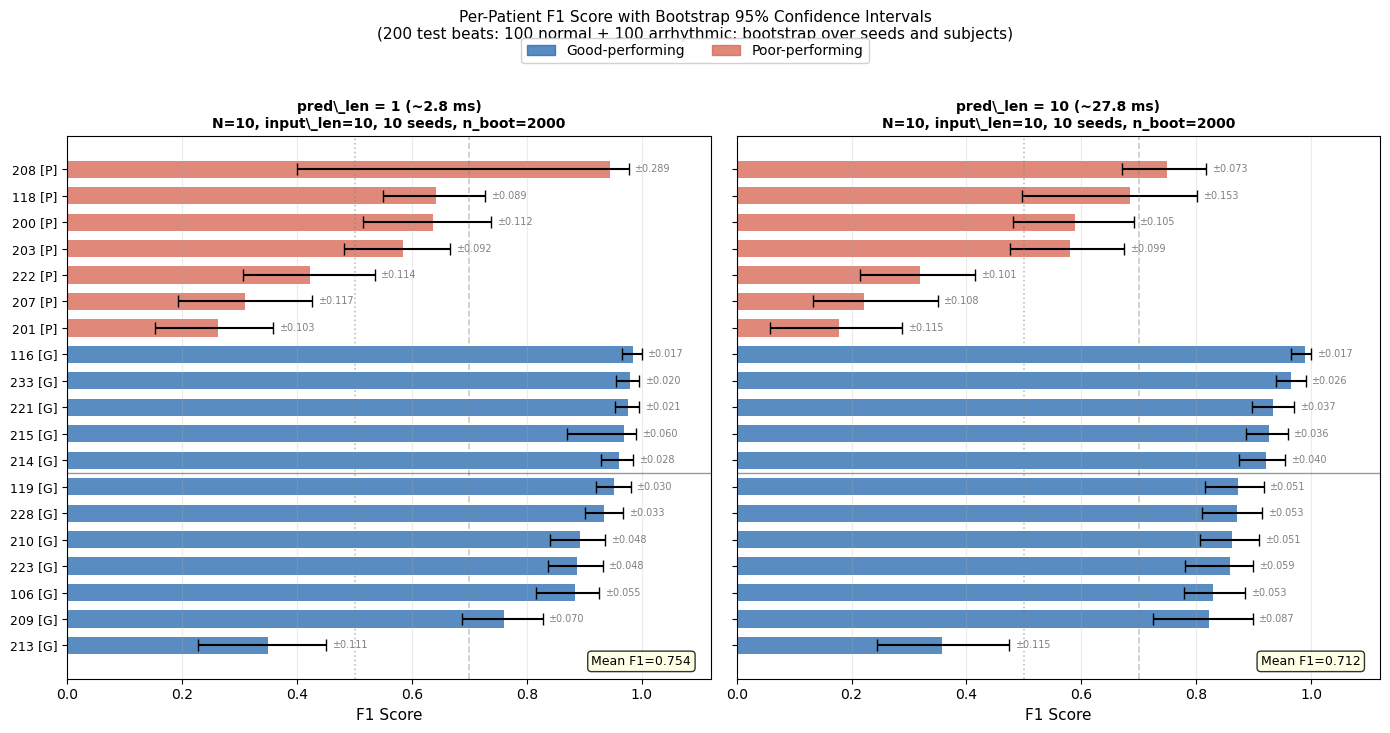


Saved: figures_bootstrap/FigS_bootstrap_CI.pdf

PAPER-READY NUMBERS

pred_len = 1:
  Mean observed F1       : 0.754 ± 0.256
  Mean 95% CI width      : 0.153 (max 0.577)
  Patients CI entirely >0.5 : 13/19
  1 misclassification ΔF1  : ~0.010 (1.0% of F1 range)

pred_len = 10:
  Mean observed F1       : 0.712 ± 0.263
  Mean 95% CI width      : 0.145 (max 0.305)
  Patients CI entirely >0.5 : 12/19
  1 misclassification ΔF1  : ~0.010 (1.0% of F1 range)

  -> Bootstrap CIs account for small-sample sensitivity
  -> Multi-seed evaluation (n=10) stabilizes estimates


In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
Fast bootstrap CI — addresses Reviewer Comment 6.
Strategy: fix N=10, input_len=10, use all 10 res_seeds per patient.
Per patient: pool flags across seeds → one bootstrap per patient.
Total: 19 patients × 2 pred_lens × 2000 boot iters = fast (<2 min).
Produces ONE publication figure: per-patient F1 + 95% CI bar chart.
"""

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────
SAVE_DIR   = "results_all_selected_patients_w1-10_N"
FIG_DIR    = "figures_bootstrap"
os.makedirs(FIG_DIR, exist_ok=True)

PATIENTS   = ['215','213','209','203','210','116','222','233',
              '118','223','221','214','200','228','201','208',
              '119','207','106']

# GOOD/POOR classification (from your paper)
GOOD_PATIENTS = {'215','213','209','210','116','233','223','221',
                 '214','228','119','106'}
POOR_PATIENTS = {'203','222','118','200','201','208','207'}

DATA_SEED  = 17
RES_SEEDS  = [1107, 1249, 1388, 1523, 1697,
              1841, 1999, 2134, 2288, 2456]
INPUT_LEN  = 10     # fix one value
N          = 10     # fix one value
PRED_LENS  = [1, 10]
N_BOOT     = 2000
N_NORM     = 100
N_ARR      = 100
TRUE_LABELS = np.array([0]*N_NORM + [1]*N_ARR)
RNG        = np.random.default_rng(42)

# ── HELPERS ───────────────────────────────────────────────────────────────

def load_flags(record, res_seed, pred_len):
    """Load final-timestep flags for one (patient, seed, pred_len) combo."""
    path = os.path.join(
        SAVE_DIR,
        "results_summary_online_detection_PCA_all_patient_"
        "{}_data_seed_{}_res_seed_{}_input_len_{}_reservoirs_{}.csv".format(
            record, DATA_SEED, res_seed, INPUT_LEN, N)
    )
    if not os.path.exists(path):
        return None
    try:
        df  = pd.read_csv(path)
        row = df[df["Pred_len"] == pred_len]
        if len(row) == 0:
            return None
        s   = row.iloc[0]["Online_results"]
        res = json.loads(s)
        flags = np.array(res[-1]["flags"], dtype=int)
        return flags if len(flags) == N_NORM + N_ARR else None
    except Exception:
        return None

def bootstrap_f1_ci(y_true, y_pred_list, n_boot=N_BOOT, rng=RNG):
    """
    Bootstrap over BOTH samples and seeds simultaneously.
    y_pred_list: list of flag arrays (one per seed).
    Returns mean, lower, upper, observed_f1.
    """
    n      = len(y_true)
    n_seed = len(y_pred_list)
    preds  = np.stack(y_pred_list, axis=0)   # (n_seeds, 200)

    boot_f1s = []
    for _ in range(n_boot):
        # resample seeds with replacement
        seed_idx   = rng.integers(0, n_seed, size=n_seed)
        # resample subjects with replacement
        subj_idx   = rng.integers(0, n, size=n)
        y_t        = y_true[subj_idx]
        # majority vote across resampled seeds for resampled subjects
        y_p        = (preds[seed_idx][:, subj_idx].mean(axis=0) >= 0.5).astype(int)
        if len(np.unique(y_t)) < 2:
            continue
        boot_f1s.append(f1_score(y_t, y_p, zero_division=0))

    boot_f1s = np.array(boot_f1s)
    # observed: majority vote across all seeds on original subjects
    obs_pred = (preds.mean(axis=0) >= 0.5).astype(int)
    obs_f1   = f1_score(y_true, obs_pred, zero_division=0)

    return {
        "obs_f1":  obs_f1,
        "mean":    float(np.mean(boot_f1s)),
        "lower":   float(np.percentile(boot_f1s, 2.5)),
        "upper":   float(np.percentile(boot_f1s, 97.5)),
        "std":     float(np.std(boot_f1s)),
        "n_seeds": n_seed,
    }

# ── MAIN LOOP ─────────────────────────────────────────────────────────────

results = []

for pred_len in PRED_LENS:
    print(f"\npred_len = {pred_len}")
    for record in PATIENTS:
        flags_list = []
        for rs in RES_SEEDS:
            f = load_flags(record, rs, pred_len)
            if f is not None:
                flags_list.append(f)

        if len(flags_list) == 0:
            print(f"  {record}: NO DATA")
            continue

        ci = bootstrap_f1_ci(TRUE_LABELS, flags_list)
        results.append({
            "Patient":   record,
            "Pred_len":  pred_len,
            "Group":     "Good" if record in GOOD_PATIENTS else "Poor",
            **ci
        })
        print(f"  {record} ({ci['n_seeds']} seeds): "
              f"F1={ci['obs_f1']:.3f}  "
              f"95%CI=[{ci['lower']:.3f}, {ci['upper']:.3f}]")

df_res = pd.DataFrame(results)
df_res.to_csv(os.path.join(FIG_DIR, "bootstrap_ci_results.csv"), index=False)

# ── FIGURE ────────────────────────────────────────────────────────────────
# One figure, two panels (pred_len=1 left, pred_len=10 right)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

COLORS = {"Good": "#2166ac", "Poor": "#d6604d"}

for ax, pred_len in zip(axes, PRED_LENS):
    sub = df_res[df_res["Pred_len"] == pred_len].sort_values(
        ["Group", "obs_f1"], ascending=[True, True]   # Poor first (bottom)
    ).reset_index(drop=True)

    y      = np.arange(len(sub))
    colors = [COLORS[g] for g in sub["Group"]]
    xerr   = np.array([
        sub["obs_f1"] - sub["lower"],
        sub["upper"]  - sub["obs_f1"]
    ])

    bars = ax.barh(y, sub["obs_f1"], xerr=xerr,
                   color=colors, alpha=0.75, capsize=4,
                   error_kw=dict(elinewidth=1.5, ecolor='black'),
                   height=0.65)

    # CI width annotation
    for i, row in sub.iterrows():
        ci_w = row["upper"] - row["lower"]
        ax.text(min(row["upper"] + 0.01, 1.02), i,
                f"±{ci_w/2:.3f}", va='center', fontsize=7, color='gray')

    ax.set_yticks(y)
    ax.set_yticklabels(
        [f"{r['Patient']} [{r['Group'][0]}]" for _, r in sub.iterrows()],
        fontsize=9
    )
    ax.set_xlabel("F1 Score", fontsize=11)
    ax.set_xlim(0, 1.12)
    ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5, lw=1.2)
    ax.axvline(0.7, color='gray', linestyle='--', alpha=0.4, lw=1.2)
    ax.grid(True, axis='x', alpha=0.25)

    # separator line between Poor and Good
    n_poor = (sub["Group"] == "Poor").sum()
    if 0 < n_poor < len(sub):
        ax.axhline(n_poor - 0.5, color='black', lw=1.0, ls='-', alpha=0.4)

    label = "~2.8 ms" if pred_len == 1 else "~27.8 ms"
    ax.set_title(
        f"pred\\_len = {pred_len} ({label})\n"
        f"N=10, input\\_len=10, {len(RES_SEEDS)} seeds, n_boot={N_BOOT}",
        fontsize=10, fontweight='bold'
    )

    # summary stats in corner
    overall_mean = sub["obs_f1"].mean()
    ax.text(0.97, 0.02, f"Mean F1={overall_mean:.3f}",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# legend
patches = [mpatches.Patch(color=COLORS["Good"], alpha=0.75, label="Good-performing"),
           mpatches.Patch(color=COLORS["Poor"], alpha=0.75, label="Poor-performing")]
fig.legend(handles=patches, loc='upper center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, 1.01), framealpha=0.9)

fig.suptitle(
    "Per-Patient F1 Score with Bootstrap 95% Confidence Intervals\n"
    "(200 test beats: 100 normal + 100 arrhythmic; bootstrap over seeds and subjects)",
    fontsize=11, y=1.04
)

plt.tight_layout()
out = os.path.join(FIG_DIR, "FigS_bootstrap_CI.pdf")
fig.savefig(out, dpi=300, bbox_inches='tight')
fig.savefig(out.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f"\nSaved: {out}")

# ── PAPER-READY NUMBERS ───────────────────────────────────────────────────

print("\n" + "="*60)
print("PAPER-READY NUMBERS")
print("="*60)
for pred_len in PRED_LENS:
    sub = df_res[df_res["Pred_len"] == pred_len]
    ci_widths = sub["upper"] - sub["lower"]
    print(f"\npred_len = {pred_len}:")
    print(f"  Mean observed F1       : {sub['obs_f1'].mean():.3f} ± {sub['obs_f1'].std():.3f}")
    print(f"  Mean 95% CI width      : {ci_widths.mean():.3f} (max {ci_widths.max():.3f})")
    print(f"  Patients CI entirely >0.5 : "
          f"{(sub['lower']>0.5).sum()}/{len(sub)}")
    print(f"  1 misclassification ΔF1  : ~{1/N_ARR:.3f} "
          f"({100/N_ARR:.1f}% of F1 range)")
print(f"\n  -> Bootstrap CIs account for small-sample sensitivity")
print(f"  -> Multi-seed evaluation (n={len(RES_SEEDS)}) stabilizes estimates")